<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/RandomForestAlgo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Machine Learning Lecture: Ensemble Techniques

Ensemble techniques combine several base models (like Decision Trees) to create one optimal predictive model. Instead of relying on a single tree, which might be inaccurate or overfit, you combine many trees to get a stable, accurate result.



##  1. Bagging (Bootstrap Aggregating)
Bagging reduces **variance** (overfitting) by training multiple models in parallel on different subsets of data.

### Architecture Flow

               [ Original Dataset ]
                /        |       \   
             (Bootstrap Sampling)[Sub-1]    [Sub-2]         [Sub-3]|          |         |[Tree-1]   [Tree-2]  [Tree-3] (Parallel Training)\          |         /[ Majority Vote / Avg ]    (Aggregating)
              [ Final Output ]

###  How it Works
* **Bootstrapping**: Create random subsets of the original dataset with replacement. Some rows repeat; some are left out.
* **Parallel Training**: Train a separate base model on each subset independently.
* **Aggregating**: Combine predictions from all models.
  * **Classification**: Uses **Majority Voting** (the class chosen by most trees wins).
  * **Regression**: Uses **Averaging** (mean of all tree outputs).

### Mathematical Intuition
If you have $N$ independent models, each with a variance of $\sigma^2$, averaging them reduces the total variance to:

$$\text{New Variance} = \frac{\sigma^2}{N}$$

### Real-World Example
Imagine you want to buy a house. Instead of asking one real estate agent (who might be biased), you ask 10 independent agents. Each agent looks at a slightly different mix of past sales data. You take the average of all 10 price estimates to get your final answer.


##  2. Random Forest
Random Forest is an extension of Bagging that adds **feature randomness** to make the trees even more independent.

###  How it Works
Standard Bagging looks at *all* features when splitting a tree node. Random Forest randomly selects a **subset of features** at each split. This prevents a single dominant, highly predictive feature from making all the trees look identical.

###  Real-World Example
Think of a medical board diagnosing a patient:
* **Standard Bagging**: Every doctor looks at all medical test results. They might all focus on the same major symptom and give similar opinions.
* **Random Forest**: Doctor A only looks at blood reports. Doctor B only looks at family history. Doctor C looks at MRI scans. They vote at the end. This diverse perspective catches hidden patterns.


##  3. Boosting
Boosting reduces **bias** (underfitting) by training multiple models sequentially, where each new model fixes the mistakes of the previous one.

###  Architecture Flow

[ Data ] -> [ Model 1 ] -> (Find Errors) -> [ Model 2 (Focuses on Errors) ] -> (Find Errors) -> [ Model 3 ]|[ Final Output ] <------------------ (Weighted Combination of All Models) <-------------------------+



###  How it Works
1. Train a weak base model (usually a shallow tree called a "stump") on the data.
2. Identify which data points the model predicted incorrectly.
3. Increase the **weights** of those incorrect data points so they become more important.
4. Train the next model on this re-weighted data. It will naturally focus on fixing the previous mistakes.
5. Repeat this sequentially. The final prediction is a **weighted sum** of all models based on their accuracy.

###  Mathematical Intuition (AdaBoost Example)
Each data point starts with equal weight $W_i = \frac{1}{M}$ (where $M$ is the total number of rows).

If a model makes an error, the error rate $\epsilon$ is calculated. The model's voice/importance ($\alpha$) in the final vote is calculated as:

$$\alpha = \frac{1}{2} \ln\left(\frac{1 - \epsilon}{\epsilon}\right)$$

* Low error ($\epsilon$) $\rightarrow$ High importance ($\alpha$).
* High error ($\epsilon$) $\rightarrow$ Low importance ($\alpha$).

###  Real-World Example
Think of a student preparing for an exam:
* **Test 1**: The student takes a practice test and gets questions 3, 5, and 8 wrong.
* **Study Session 2**: The student spends 80% of their time studying topics from questions 3, 5, and 8.
* **Test 2**: The student takes a new test, does better on those topics, but misses question 10.
* **Study Session 3**: The student focuses heavily on question 10.
* Eventually, the student masters all topics by fixing errors step-by-step.

---

##  4. Summary: When to Use Which?


| Metric | Use Bagging (Random Forest) | Use Boosting (XGBoost, LightGBM) |
| :--- | :--- | :--- |
| **Main Goal** | Reduce Variance (Stop Overfitting). | Reduce Bias (Fix Underfitting). |
| **Data Quality** | Great if data has lots of noise/outliers. | Requires clean data; highly sensitive to outliers. |
| **Training Speed** | Fast. Trees train simultaneously (Parallel). | Slower. Trees train one after another (Sequential). |
| **Tuning Effort** | Easy. Works well out of the box. | Hard. Requires careful tuning of learning rates. |




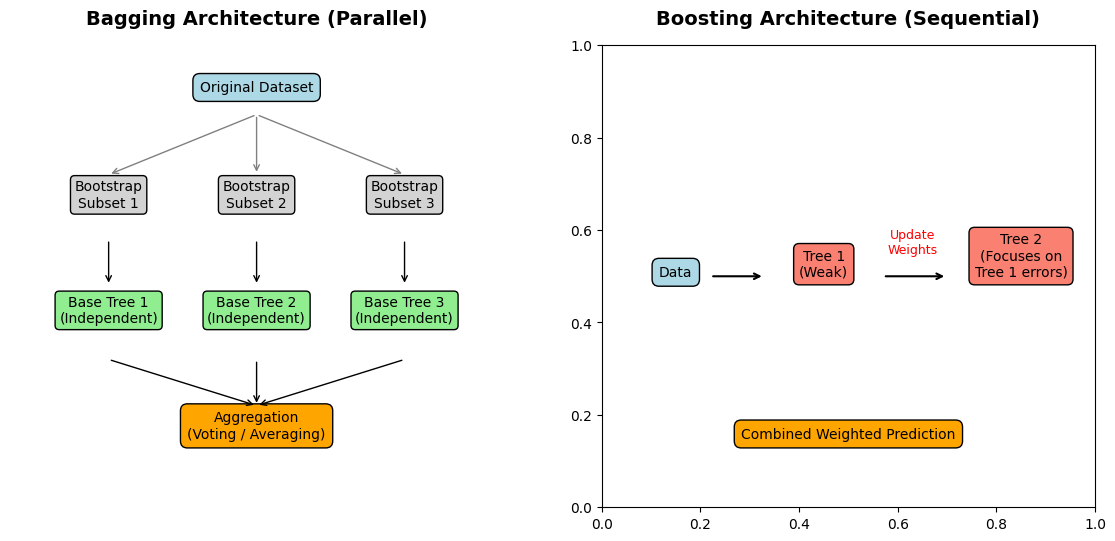